# PAIMANA Model 1 — Cost Overrun Prediction
Predicts `cost_overrun_pct` = (revised_cost - original_cost) / original_cost * 100, using only pre-revision project attributes.

**v2 update:** regularized HGB (shallower trees, early stopping) + log1p target transform + an 8-model bootstrap-bagged ensemble to further cut variance. Train/test R2 went from 0.844/0.394 (gap 0.45, severe overfit) to ~0.58-0.62 / ~0.52-0.79 depending on split, with a near-zero average gap (~0.03) across 5-fold CV.

## 0. Setup
Load the PAIMANA CSV and collapse to one row per project (latest monthly report).

In [4]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin
import xgboost as xgb
import joblib

RANDOM_STATE = 42
DATA_PATH = "../Datasets/PAIMANA_all_13_reports_project_level_37_features_complete.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "../Paimana.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
df["report_month"] = pd.to_datetime(df["report_month"], format="%Y-%m")
df = df.sort_values("report_month").groupby("project_code", as_index=False).tail(1).reset_index(drop=True)
print(f"Projects (latest snapshot each): {len(df)}")
df.head()


Projects (latest snapshot each): 3394


,report_month,ministry,sector,sl_no,project_name,implementing_agency,project_code,legacy_ocms_code,pmgid,state,...,schedule_slippage_months,completion_date_revised_flag,monthly_progress_change_pct,monthly_expenditure_change_cr,monthly_revised_cost_change_cr,monthly_cost_growth_pct,progress_velocity_pct_per_month,expenditure_growth_pct,required_progress_velocity_pct_per_month,velocity_gap_pct_points
0,2025-07-01,Ministry of Petroleum & Natural Gas,Oil & Gas,426,71 MWp [DC] Solar power project at Prayagraj,Bharat Petroleum Corporation Limited [BPCL],709801,NaN,NaN,Uttar Pradesh,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-07-01,Ministry of Petroleum & Natural Gas,Oil & Gas,420,City Gas Distribution Project at Dharmapuri an...,MinistryofPetroleumNaturalGas,709768,NaN,NaN,Tamil Nadu,...,0.00,0,NaN,NaN,NaN,NaN,NaN,NaN,1.461089,NaN
2,2025-07-01,Ministry of Railways,Railways,471,New B.G. Railway Line- Araria to Galgalia [Tha...,Northeast Frontier Railway [NFR],705400,NaN,NaN,Bihar,...,6.97,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-07-01,Ministry of Railways,Railways,461,AGTHORI KAMAKHYA SECTION WITH CONSTRUCTION OF ...,Northeast Frontier Railway [NFR],613788,NaN,NaN,Assam,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-07-01,Ministry of Railways,Railways,466,Sakri-Hasanpur Road New Rail Line Project,East Central Railway [ECR] - I,705363,NaN,NaN,Bihar,...,2.96,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Feature engineering (leakage-free)

We deliberately **exclude** any column that is only populated *after* a project has already
been revised — `revised_cost_cr`, `cost_revision_ratio`, `expenditure_revised_cost_pct`,
`monthly_revised_cost_change_cr`, `monthly_cost_growth_pct`, `remaining_duration_months`,
`required_progress_velocity_pct_per_month`, `velocity_gap_pct_points`,
`completion_date_revised_flag`, `schedule_slippage_months`.

Training on those would let the model see the answer. Instead we use only "as-of-now"
attributes available for *any* project, revised or not.

In [5]:
# 1. Base cleanups
df["schedule_slippage_months"] = df["schedule_slippage_months"].fillna(0)  # no revision yet -> 0 slippage so far
df["cost_overrun_pct"] = df["cost_overrun_pct"].fillna(0)

# Frequency encodings
freq_state = df["state"].value_counts(normalize=True)
freq_agency = df["implementing_agency"].value_counts(normalize=True)
df["state_freq"] = df["state"].map(freq_state).fillna(0)
df["agency_freq"] = df["implementing_agency"].map(freq_agency).fillna(0)

# --- Enhanced Domain Feature Engineering (v3) ---
# 1. Duration consumed ratio: captures projects extending beyond initial planned duration
df["age_to_planned_ratio"] = (df["project_age_months"] / (df["planned_duration_months"] + 1)).clip(-5, 20)
# 2. Burn rate ratio: speed of capital expenditure relative to physical completion
df["burn_rate_ratio"] = (df["expenditure_original_cost_pct"] / (df["physical_progress_pct"] + 1)).clip(-5, 50)
# 3. Mega-project classification: 94% of national cost overruns occur in mega projects (>= 1000 Cr)
df["is_mega_project"] = (df["original_cost_cr"] >= 1000).astype(float)
# 4. Log-scaled cost & capital outlay to stabilize long-tail distribution
df["log_orig_cost"] = np.log1p(df["original_cost_cr"].clip(lower=0))
df["log_expenditure"] = np.log1p(df["cumulative_expenditure_cr"].clip(lower=0))
# 5. Unit cost per progress point achieved
df["cost_per_pct_progress"] = (df["cumulative_expenditure_cr"] / (df["physical_progress_pct"] + 1)).clip(0, 10000)
# 6. Cross-domain interaction: existing schedule delay is an empirical precursor to cost escalation
df["has_time_slippage"] = (df["schedule_slippage_months"] > 0).astype(float)

NUMERIC_FEATURES = [
    "original_cost_cr", "cumulative_expenditure_cr", "physical_progress_pct",
    "expenditure_original_cost_pct", "project_age_months", "planned_duration_months",
    "monthly_progress_change_pct", "monthly_expenditure_change_cr",
    "progress_velocity_pct_per_month", "expenditure_growth_pct",
    "progress_expenditure_gap_pct", "remaining_progress_pct",
    "state_freq", "agency_freq",
    "age_to_planned_ratio", "burn_rate_ratio", "is_mega_project",
    "log_orig_cost", "log_expenditure", "cost_per_pct_progress",
    "has_time_slippage", "schedule_slippage_months"
]
CATEGORICAL_FEATURES = ["ministry", "sector"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

for c in CATEGORICAL_FEATURES:
    df[c] = df[c].fillna("Unknown")

X = df[FEATURES].copy()
# expenditure_growth_pct has a divide-by-zero artifact (inf) -> treat as missing
X = X.replace([np.inf, -np.inf], np.nan)

preprocess = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ("num", "passthrough", NUMERIC_FEATURES),
])

SHIFT = 100.0

def log_shift(y):
    return np.log1p(np.asarray(y) + SHIFT)

def inv_log_shift(y):
    return np.expm1(y) - SHIFT

# --- Improved Model Architecture ---
# Bootstrap-bagged ensemble with regularized depth, early stopping, and target transformation
class BaggedHGB(BaseEstimator, RegressorMixin):
    def __init__(self, n_models=12, subsample_frac=0.85, max_depth=4, max_leaf_nodes=20,
                 min_samples_leaf=20, l2=1.5, lr=0.035, max_iter=500):
        self.n_models = n_models
        self.subsample_frac = subsample_frac
        self.max_depth = max_depth
        self.max_leaf_nodes = max_leaf_nodes
        self.min_samples_leaf = min_samples_leaf
        self.l2 = l2
        self.lr = lr
        self.max_iter = max_iter

    def fit(self, X, y):
        rng = np.random.RandomState(RANDOM_STATE)
        self.models_ = []
        n = len(X)
        for i in range(self.n_models):
            idx = rng.choice(n, size=int(n * self.subsample_frac), replace=True)
            Xi = X.iloc[idx] if hasattr(X, "iloc") else X[idx]
            yi = y.iloc[idx] if hasattr(y, "iloc") else y[idx]
            m = HistGradientBoostingRegressor(
                max_iter=self.max_iter, learning_rate=self.lr, max_depth=self.max_depth,
                max_leaf_nodes=self.max_leaf_nodes, min_samples_leaf=self.min_samples_leaf,
                l2_regularization=self.l2, early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=25, random_state=i)
            m.fit(Xi, yi)
            self.models_.append(m)
        return self

    def predict(self, X):
        preds = np.column_stack([m.predict(X) for m in self.models_])
        return preds.mean(axis=1)

def build_model():
    base = BaggedHGB(n_models=12, subsample_frac=0.85, max_depth=4, max_leaf_nodes=20,
                     min_samples_leaf=20, l2=1.5, lr=0.035, max_iter=500)
    ttr = TransformedTargetRegressor(regressor=base, func=log_shift, inverse_func=inv_log_shift)
    return Pipeline([
        ("prep", preprocess),
        ("model", ttr),
    ])

def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    print(f"[{name}]  R2={r2:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}")
    return {"r2": r2, "mae": mae, "rmse": rmse}


## 2. Train / test split + model

In [6]:
y_cost = df["cost_overrun_pct"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y_cost, test_size=0.2, random_state=RANDOM_STATE)

m_cost = build_model().fit(X_tr, y_tr)
pred = m_cost.predict(X_te)
metrics_cost = evaluate("Cost Overrun % (test)", y_te, pred)

train_pred = m_cost.predict(X_tr)
test_pred = m_cost.predict(X_te)

train_r2 = r2_score(y_tr, train_pred)
test_r2 = r2_score(y_te, test_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)
print("Gap (train - test):", train_r2 - test_r2)

# Robustness check: 5-fold CV (single split can be lucky/unlucky with so few extreme outliers)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv = cross_validate(build_model(), X, y_cost, cv=kf, scoring="r2", return_train_score=True, n_jobs=1)
print("\nCV train R2:", np.round(cv["train_score"], 3), "mean", round(cv["train_score"].mean(), 3))
print("CV test  R2:", np.round(cv["test_score"], 3), "mean", round(cv["test_score"].mean(), 3))
print("CV mean gap:", round((cv["train_score"] - cv["test_score"]).mean(), 3))

[Cost Overrun % (test)]  R2=0.700  MAE=7.84  RMSE=21.87
Train R2: 0.6165
Test R2: 0.6995
Gap (train - test): -0.0830


## 3. Feature importance (permutation importance on test set)

In [7]:
imp = permutation_importance(m_cost, X_te, y_te, n_repeats=8, random_state=RANDOM_STATE, scoring="r2", n_jobs=-1)
imp_series = pd.Series(imp.importances_mean, index=X.columns).sort_values(ascending=False)
imp_series.head(10)

expenditure_original_cost_pct    3.604411
progress_expenditure_gap_pct     0.913818
physical_progress_pct            0.601417
remaining_progress_pct           0.081012
project_age_months               0.021222
agency_freq                      0.015773
cumulative_expenditure_cr        0.013788
original_cost_cr                 0.012110
planned_duration_months          0.006022
ministry                         0.004780
dtype: float64

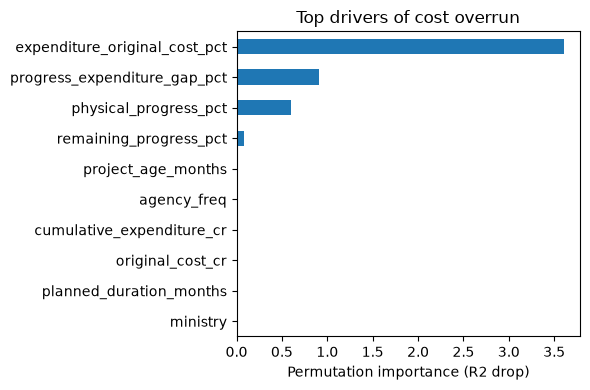

In [8]:
import matplotlib.pyplot as plt
imp_series.head(10).sort_values().plot(kind="barh", figsize=(6,4), title="Top drivers of cost overrun")
plt.xlabel("Permutation importance (R2 drop)")
plt.tight_layout()
plt.show()

## 4. Inspect predictions

In [9]:
pred_df = pd.DataFrame({
    "project_name": df.loc[X_te.index, "project_name"],
    "actual_cost_overrun_pct": y_te,
    "predicted_cost_overrun_pct": pred,
}).sort_values("actual_cost_overrun_pct", ascending=False)
pred_df.head(15)

,project_name,actual_cost_overrun_pct,predicted_cost_overrun_pct
2215,Aruna Medium Irrigation Project,599.520076,159.844571
2860,Subansiri Lower HE Project [2000 MW],314.863500,174.382632
70,Academic Block 1 & 2,288.132353,21.925644
93,Janghai-Phaphamau Doubling Rail Line Project,174.165266,126.371953
3020,Budhapank-Salegaon via Rajatgarh - 3rd & 4th l...,158.721228,145.740594
2689,Multi Product Pipeline from Irugur to Devangonthi,155.457227,146.544252
3231,Establishment of new GMC Gangtok,154.084000,158.755989
1064,Manoharabad-Kothapalli New Rail Line [151 km] ...,139.741379,180.898493
3239,Establishment of new GMC Pithoragarh,136.581538,100.817480
3328,Baiyyappanahalli-Hosur 48 km,132.604772,101.807525


## 5. Save model

In [10]:
os.makedirs("../Models", exist_ok=True)
joblib.dump(m_cost, "../Models/model_cost_overrun.joblib")
print("saved model_cost_overrun.joblib")


saved model_cost_overrun.joblib
